0.002777777777777777


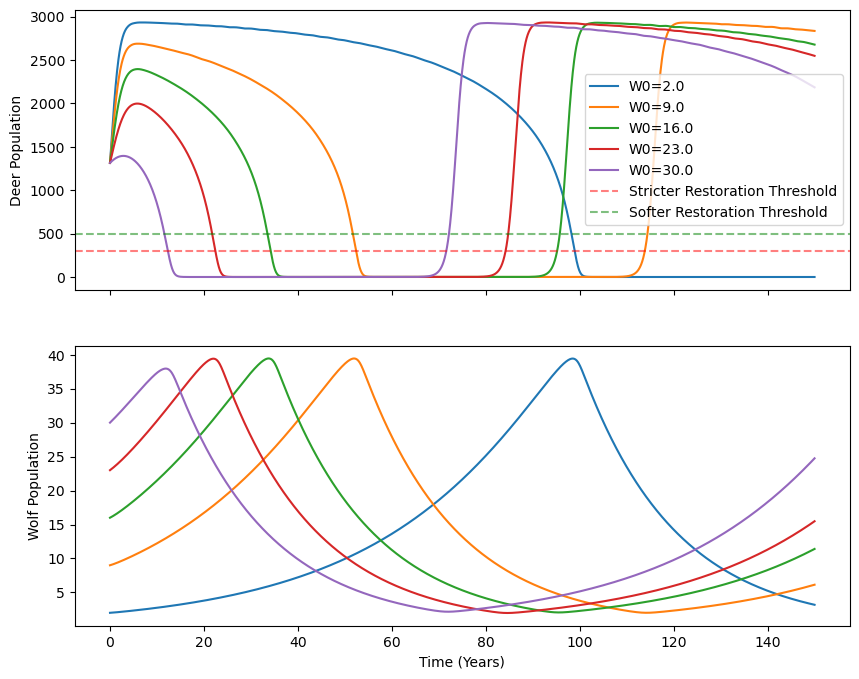

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ODE system with Holling Type II & Logistic Growth
def wolf_deer_holling(t, y, params):
    D, W = y
    r, e, beta, d, h, K = params
    
    # Holling Type II functional response
    predation = (e * D * W) / (1 + h * e * D)
    
    # Logistic growth for deer + predation
    dDdt = r * D * (1 - D/K) - predation
    
    # Wolf growth based on saturated consumption
    dWdt = beta * predation - d * W
    
    return [dDdt, dWdt]

def simulate_holling(params, D0, W0, t_max=150):
    t_eval = np.linspace(0, t_max, 2000)
    sol = solve_ivp(wolf_deer_holling, [0, t_max], [D0, W0], 
                    args=(params,), t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1]

# --- Parameters ---
# --- Parameters ---
D_star = 423 #  414
r = 1.138      # deer birth rate - death rate
h = 0.03       # handling time - NOT FULLY ACCURATE
e = -18/(18*h*D_star - D_star) #-18/(18*h*D_star - D_star)  # attack rate - want it to go up to improve dynamics 
d = 0.05       # wolf death rate
beta = (d*(1+h*e*D_star))/(e*D_star)   # conversion efficiency - independent of D_star (as expected) - want it to go up to improve dynamics
print(beta)
K = 3000      # deer carrying capacity
# as D_star goes down, model becomes more sensitive to handling time!

params = (r, e, beta, d, h, K)

# Initial populations
D0 = 1315
W0_values = np.linspace(2, 30, 5) 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for W0 in W0_values:
    t, D, W = simulate_holling(params, D0, W0)
    ax1.plot(t, D, label=f"W0={W0}")
    ax2.plot(t, W, label=f"W0={W0}")

ax1.axhline(300, color='red', linestyle='--', alpha=0.5, label="Stricter Restoration Threshold")
ax1.axhline(500, color='green', linestyle='--', alpha=0.5, label="Softer Restoration Threshold")
ax1.set_ylabel("Deer Population")
ax1.legend()
ax2.set_xlabel("Time (Years)")
ax2.set_ylabel("Wolf Population")
plt.show()

In [ ]:
# --- Parameters ---
D_star = 414   #
r = 1.138      # deer birth rate - death rate
h = 0.03       # handling time 
e = 0.18/D_star #-18/(18*h*D_star - D_star)  # attack rate - want it to go up to improve dynamics 
print(e)
print(18/D_star)
d = 0.05       # wolf death rate
beta = (d*(1+h*e*D_star))/(e*D_star)   # conversion efficiency - independent of D_star (as expected) - want it to go up to improve dynamics
print(beta)
K = 1700      # deer carrying capacity